# Conditional Graph

In [1]:
# import
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
# schema
class AgentState(TypedDict):
    number_1: int
    operation: str
    number_2: int
    final_answer: int

In [3]:
# node functions
def adder(state: AgentState) -> AgentState:
    """This node will add 2 numbers"""
    state['final_answer'] = state['number_1'] + state['number_2']

    return state

def subtractor(state: AgentState) -> AgentState:
    """This node will substract to one number from another."""
    state['final_answer'] = state['number_1'] - state['number_2']

    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node of the graph."""
    if state['operation'] == '+':
        return "add_operation"

    elif state['operation'] == '-':
        return "sub_operation"

In [4]:
graph = StateGraph(AgentState)

graph.add_node('add_node', adder)
graph.add_node('sub_node', subtractor)
graph.add_node('router', lambda state: state) # passthrough fn

graph.add_edge(START, 'router')

graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        "add_operation": "add_node",
        "sub_operation": "sub_node"
    }
)

graph.add_edge('add_node', END)
graph.add_edge('sub_node', END)

app = graph.compile()

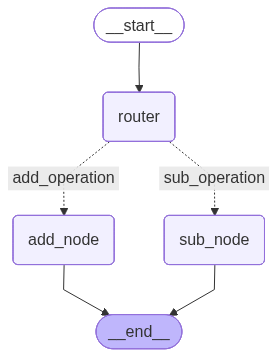

In [5]:
# visualize

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
initial_state = AgentState(number_1 = 10, number_2 = 5, operation = '-')

result = app.invoke({'number_1': 10, 'number_2': 5, 'operation': '-'})
print(result['final_answer'])

5
